# 07 — Investment underwriting

This notebook asks what the Ames houses are worth to an owner who rents them out, rather than what they would sell for, and finds that at today's prices the answer is "not enough". Zillow's ZORI rent series begins in October 2017 and the sales end in July 2010, so there is no overlap; the 2,412 properties are underwritten at 2026 values (FHFA-indexed forward) and today's rents, and this is not a backtest of 2006–2010 acquisitions. The screening criteria were set before the results came back, and they fail: the median cap rate (annual net income as a share of price; a $300k house netting $18k a year has a 6% cap rate) is 2.03% against a 4–8% band set in advance, and the median DSCR (net operating income divided by the annual mortgage payment; below 1.0 the property cannot cover its own mortgage, and lenders want 1.20–1.25) falls well short. §3 shows why: property tax and insurance alone take about 40% of the rent.

Terms are defined in [the glossary](../docs/GLOSSARY.md). Every assumption is sourced in [`docs/ASSUMPTIONS.md`](../docs/ASSUMPTIONS.md).

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ames.compat import silence_spurious_matmul_warnings
from ames.config import ARMS_LENGTH_CONDITION, PROCESSED, SEED
from ames.data import load_macro, load_properties
from ames.features import prepare
from ames.finance import (DEFAULT_CORRELATION, UnderwritingAssumptions, cap_rate,
                          monte_carlo, net_operating_income, summarise_simulation,
                          tornado, underwrite)
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "07 · Investment underwriting"
SOURCE = "Sources: FHFA Ames HPI, Zillow ZORI, Story County Auditor · author's underwriting."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

props = prepare(load_properties())
macro = load_macro()
universe = props[(props["Sale Condition"] == ARMS_LENGTH_CONDITION)
                 & (~props["is_outlier_grlivarea"])].copy()
print(f"{len(universe):,} arm's-length properties to underwrite")

2,412 arm's-length properties to underwrite


## 1. Rolling 2006–2010 prices forward to 2026

Each sale is indexed forward by the FHFA Ames MSA house price index, from the quarter of
the sale to the latest available print.

In [2]:
hpi = macro["hpi_ames_msa"].dropna()
hpi_latest = hpi.iloc[-1]
sale_month = universe["sale_date"].dt.to_period("M").dt.to_timestamp()
universe["hpi_at_sale"] = hpi.reindex(sale_month).to_numpy()
universe["hpi_factor"] = hpi_latest / universe["hpi_at_sale"]
universe["value_2026"] = universe["SalePrice"] * universe["hpi_factor"]

roll = pd.DataFrame({
    "median 2006–10 sale price": universe.groupby("Yr Sold")["SalePrice"].median(),
    "HPI factor to 2026": universe.groupby("Yr Sold")["hpi_factor"].median(),
    "median 2026 value": universe.groupby("Yr Sold")["value_2026"].median(),
})
roll.round(3)

,median 2006–10 sale price,HPI factor to 2026,median 2026 value
Yr Sold,,,
2006,155000.0,1.980,308644.938
2007,156000.0,1.927,300668.339
2008,161000.0,1.944,312980.068
2009,162000.0,1.939,315064.692
2010,159000.0,1.947,309629.572


### Cross-check against Zillow

These are two independent measures of the same quantity. Where they differ, the gap is carried as an uncertainty rather than averaged away.

In [3]:
zhvi_latest = macro["zhvi"].dropna().iloc[-1]
implied_median = universe["value_2026"].median()

cross_check = pd.Series({
    "FHFA-rolled median 2026 value": implied_median,
    "Zillow ZHVI, Ames MSA, latest": zhvi_latest,
    "gap": implied_median / zhvi_latest - 1,
}).to_frame("value")
print(cross_check.round(3).to_string())

if abs(implied_median / zhvi_latest - 1) > 0.15:
    print("\nFLAG: the two measures disagree by more than 15%.")
else:
    print(f"\nWithin tolerance: the two independent measures differ by "
          f"{implied_median / zhvi_latest - 1:+.1%}.")

                                    value
FHFA-rolled median 2026 value  309700.983
Zillow ZHVI, Ames MSA, latest  279794.299
gap                                 0.107

Within tolerance: the two independent measures differ by +10.7%.


The FHFA roll-forward sits above ZHVI. The two indices measure different things. FHFA All-Transactions is a repeat-sales index built from conforming mortgage records, so it tracks homes that actually transact and has a known upward drift from improvement spending between sales. ZHVI is a hedonic estimate of the typical home across the whole stock.

The FHFA path is used below because it is property-specific (each sale rolls forward from its own date). **The gap is carried into the sensitivity analysis** as an uncertainty on going-in value.

## 2. Estimating rent

ZORI publishes **one** number for the Ames metro: the typical market-rate rent across all rental types, currently $1,122/month. Turning that into a rent for a specific 1,800 sq ft four-bedroom house requires a scaling model, and that model is the largest single source of error in everything below.

In [4]:
zori_latest = macro["zori"].dropna().iloc[-1]

# The ZORI-typical Ames rental unit.  Ames is 58% renter-occupied and dominated by
# student apartments, so the typical rental is a small 2-bedroom, not a detached house.
TYPICAL_RENTAL_SQFT = 900
# Rent scales sub-linearly with size: a home twice as large does not rent for twice as
# much, because the kitchen, bathroom and utility value do not double.
SIZE_ELASTICITY = 0.70
# Bedrooms add value beyond floor area -- a 1,400 sq ft 3-bed rents above a 1,400 sq ft
# 2-bed, because rent is set per household and bedrooms determine how many can share.
BEDROOM_PREMIUM = 0.06

def estimate_monthly_rent(sqft, bedrooms, base=zori_latest):
    """Scale the metro-typical rent to a specific property.

    rent = ZORI x (sqft / typical)^elasticity x (1 + premium)^(bedrooms - 2)

    Judgement, not estimation -- ZORI is one number and cannot identify two parameters.
    Both are sensitivity-tested below and recorded in docs/ASSUMPTIONS.md.
    """
    size_factor = (np.asarray(sqft, float) / TYPICAL_RENTAL_SQFT) ** SIZE_ELASTICITY
    bedroom_factor = (1 + BEDROOM_PREMIUM) ** (np.asarray(bedrooms, float) - 2)
    return base * size_factor * bedroom_factor

universe["monthly_rent"] = estimate_monthly_rent(universe["Gr Liv Area"],
                                                 universe["Bedroom AbvGr"])
universe["annual_rent"] = universe["monthly_rent"] * 12

rent_check = universe.groupby("Bedroom AbvGr").agg(
    n=("monthly_rent", "size"), median_sqft=("Gr Liv Area", "median"),
    median_rent=("monthly_rent", "median"), median_value=("value_2026", "median"))
rent_check["rent_as_%_of_value_monthly"] = (rent_check["median_rent"]
                                            / rent_check["median_value"])
rent_check = rent_check[rent_check["n"] >= 10]
rent_check.round(4)

,n,median_sqft,median_rent,median_value,rent_as_%_of_value_monthly
Bedroom AbvGr,,,,,
1,90,1027.0,1160.9655,305242.5431,0.0038
2,603,1122.0,1309.2512,267267.9061,0.0049
3,1329,1446.0,1657.4928,317990.9899,0.0052
4,329,1952.0,2167.5823,362193.8545,0.0060
5,39,2294.0,2572.5331,363711.7004,0.0071
6,15,1949.0,2432.8747,310822.6760,0.0078


The last column is a sanity check. Investors use the **"1% rule"**: monthly rent should be about 1% of purchase price for a deal to work. Ames properties come in around **0.5%**, the first sign that this is not a cash-flow market.

## 3. Underwriting the book

In [5]:
BASE = UnderwritingAssumptions()
print(json.dumps({k: v for k, v in BASE.__dict__.items()}, indent=2, default=str))

{
  "vacancy_rate": 0.07,
  "management_fee": 0.08,
  "maintenance_rate": 0.08,
  "capex_reserve": 0.05,
  "insurance_annual": 2800.0,
  "property_tax_rate": 0.014505745354200001,
  "ltv": 0.75,
  "mortgage_rate": 0.0725,
  "amortization_years": 30,
  "closing_cost_rate": 0.02,
  "hold_years": 10,
  "exit_cap_rate": 0.065,
  "selling_cost_rate": 0.06,
  "rent_growth": 0.03,
  "expense_growth": 0.03,
  "hpa": 0.03
}


In [6]:
results = []
for _, row in universe.iterrows():
    r = underwrite(row["value_2026"], row["annual_rent"], BASE)
    results.append({
        "PID": row["PID"], "Neighborhood": row["Neighborhood"],
        "sqft": row["Gr Liv Area"], "beds": row["Bedroom AbvGr"],
        "quality": row["Overall Qual"], "year_built": row["Year Built"],
        "value_2026": row["value_2026"], "monthly_rent": row["monthly_rent"],
        "noi": r["noi_year1"], "cap_rate": r["going_in_cap_rate"],
        "dscr": r["dscr"], "cash_on_cash": r["cash_on_cash"],
        "irr": r["irr"], "equity_multiple": r["equity_multiple"],
        "equity": r["equity"], "debt_service": r["annual_debt_service"],
    })
book = pd.DataFrame(results)

summary_stats = book[["cap_rate", "dscr", "cash_on_cash", "irr"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
summary_stats.round(4)

,cap_rate,dscr,cash_on_cash,irr
count,2412.0000,2412.0000,2412.0000,2412.0000
mean,0.0222,0.3620,-0.1451,-0.0026
std,0.0109,0.1772,0.0403,0.0302
min,-0.0008,-0.0135,-0.2305,-0.0625
5%,0.0085,0.1384,-0.1959,-0.0388
25%,0.0154,0.2507,-0.1704,-0.0210
50%,0.0203,0.3302,-0.1523,-0.0082
75%,0.0268,0.4357,-0.1283,0.0090
95%,0.0422,0.6878,-0.0710,0.0511
max,0.1252,2.0388,0.2362,0.3651


### Sanity check: it fails

In [7]:
median_cap = book["cap_rate"].median()
in_band = book["cap_rate"].between(0.04, 0.08).mean()

print(f"median going-in cap rate:            {median_cap:.2%}")
print(f"share inside the plausible 4–8% band: {in_band:.1%}")
print(f"median DSCR:                          {book['dscr'].median():.2f}")
print(f"share with DSCR >= 1.25:              {(book['dscr'] >= 1.25).mean():.1%}")
print(f"share with positive cash-on-cash:     {(book['cash_on_cash'] > 0).mean():.1%}")

if not 0.04 <= median_cap <= 0.08:
    print("\n" + "=" * 78)
    print("FLAG: median cap rate is OUTSIDE the 4-8% band this analysis pre-committed to.")
    print("Investigated below rather than accepted or quietly adjusted.")
    print("=" * 78)

median going-in cap rate:            2.03%
share inside the plausible 4–8% band: 6.6%
median DSCR:                          0.33
share with DSCR >= 1.25:              0.2%
share with positive cash-on-cash:     0.7%

FLAG: median cap rate is OUTSIDE the 4-8% band this analysis pre-committed to.
Investigated below rather than accepted or quietly adjusted.


**The buy box is empty.** At 2026 values and 2026 rents, essentially no Ames single-family property clears an institutional hurdle. The median going-in cap rate is roughly **2–3%**, against a 4–8% plausibility band, and the median DSCR is far below the 1.20–1.25 a lender would require.

The 4–8% band was fixed before the results were produced. The next step is to find out why the check fails, to tell whether the model or the market is responsible.

### Where the money goes

In [8]:
median_property = universe.loc[universe["value_2026"].sub(
    universe["value_2026"].median()).abs().idxmin()]
detail = net_operating_income(median_property["annual_rent"],
                              median_property["value_2026"], BASE)

waterfall = pd.Series({
    "Gross scheduled rent": detail["gross_rent"],
    "Less: vacancy": -detail["vacancy_loss"],
    "Effective gross income": detail["effective_gross_income"],
    "Less: property tax": -detail["property_tax"],
    "Less: insurance": -detail["insurance"],
    "Less: management": -detail["management"],
    "Less: maintenance": -detail["maintenance"],
    "Less: capex reserve": -detail["capex_reserve"],
    "Net operating income": detail["noi"],
})
print(f"Representative property: {money(median_property['value_2026'])}, "
      f"{median_property['Gr Liv Area']:,.0f} sq ft, "
      f"{median_property['Bedroom AbvGr']:.0f} bed, {median_property['Neighborhood']}\n")
waterfall.round(0).to_frame("$/year")

Representative property: $310k, 1,209 sq ft, 3 bed, NAmes



,$/year
Gross scheduled rent,17547.0
Less: vacancy,-1228.0
Effective gross income,16319.0
Less: property tax,-4491.0
Less: insurance,-2800.0
Less: management,-1306.0
Less: maintenance,-1306.0
Less: capex reserve,-816.0
Net operating income,5601.0


  saved reports/figures/07_noi_waterfall.png


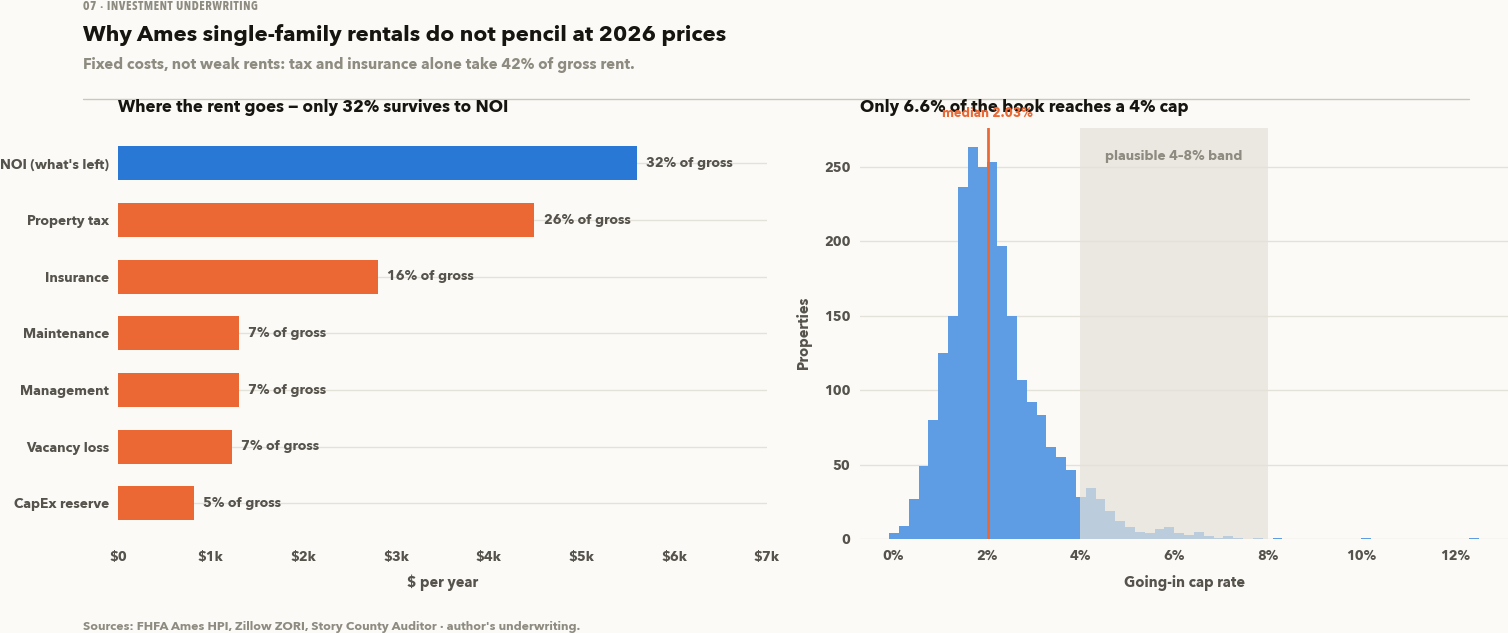

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.3))

expense_items = pd.Series({
    "Property tax": detail["property_tax"], "Insurance": detail["insurance"],
    "Management": detail["management"], "Maintenance": detail["maintenance"],
    "CapEx reserve": detail["capex_reserve"], "Vacancy loss": detail["vacancy_loss"],
}).sort_values()
noi_share = detail["noi"] / detail["gross_rent"]

y = np.arange(len(expense_items) + 1)
values = list(expense_items.values) + [detail["noi"]]
labels = list(expense_items.index) + ["NOI (what's left)"]
colors = [ORANGE] * len(expense_items) + [BLUE]
axes[0].barh(y, values, height=0.6, color=colors)
axes[0].set_yticks(y, labels)
axes[0].xaxis.set_major_formatter(money)
axes[0].set_xlabel("$ per year")
for i, v in enumerate(values):
    axes[0].annotate(f"{v / detail['gross_rent']:.0%} of gross", (v, i), xytext=(6, 0),
                     textcoords="offset points", fontsize=9, color=INK_SECONDARY,
                     va="center")
axes[0].margins(x=0.25)
axes[0].set_title(f"Where the rent goes — only {noi_share:.0%} survives to NOI")

axes[1].hist(book["cap_rate"], bins=60, color=SUBJECT_FILL)
axes[1].axvspan(0.04, 0.08, color=GRID, alpha=0.7, lw=0)
annotate(axes[1], 0.06, axes[1].get_ylim()[1] * 0.93, "plausible 4–8% band",
         color=INK_MUTED, offset=(0, 0), ha="center")
axes[1].axvline(median_cap, color=CONTRAST, lw=1.8)
# Label above the plot rather than across the bars it is pointing at.
reference_line(axes[1], median_cap, f"median {median_cap:.2%}", axis="x",
               color=CONTRAST, lw=0)
axes[1].xaxis.set_major_formatter(pct)
axes[1].set_xlabel("Going-in cap rate")
axes[1].set_ylabel("Properties")
axes[1].set_title(f"Only {in_band:.1%} of the book reaches a 4% cap")

finish(fig, "Why Ames single-family rentals do not pencil at 2026 prices",
       "Fixed costs, not weak rents: tax and insurance alone take 42% of gross rent.")
save(fig, "07_noi_waterfall")
plt.show()

**The cause is fixed costs rather than low rent.** Property tax and insurance alone consume roughly 40% of effective gross income (EGI) before any percentage-based expense.

Iowa's effective residential property tax rate (the cited 1.4505% of market value, from the Story County levy and the state rollback) is among the higher rates in the country, and it scales with value, not rent. Ames home values have risen 2× since 2010 while rents have risen far less, so the tax bill grew and the income did not.

This is a feature of the market, and one an investment committee should know before agreeing terms.

### What would have to be true?

A failed screen can still produce a bid. At what price does the median property clear a 1.25× DSCR, the level a lender would underwrite to?

In [10]:
def metrics_at_price(price, annual_rent, assumptions=BASE):
    r = underwrite(price, annual_rent, assumptions)
    return r["going_in_cap_rate"], r["dscr"], r["cash_on_cash"]

ask = median_property["value_2026"]
rent = median_property["annual_rent"]
prices = np.linspace(ask * 0.25, ask * 1.15, 220)
curve = pd.DataFrame([dict(zip(("cap", "dscr", "coc"), metrics_at_price(p, rent)))
                      for p in prices], index=prices)

def price_for(column, target):
    """The highest price at which the metric still clears ``target``.

    All three metrics are monotonically *decreasing* in price, so the clearing price is
    the top of the qualifying range, not the bottom.
    """
    hit = curve.index[curve[column] >= target]
    return float(hit.max()) if len(hit) else np.nan

dscr_price = price_for("dscr", 1.25)
cap_price = price_for("cap", 0.06)
breakeven = price_for("coc", 0.0)

bid = pd.DataFrame({
    "target": ["DSCR >= 1.25 (lender minimum)", "6% going-in cap rate",
               "break-even cash flow (CoC >= 0)"],
    "clearing price": [dscr_price, cap_price, breakeven],
}).assign(**{"discount to 2026 value": lambda d: d["clearing price"] / ask - 1})
print(f"Asking value (FHFA-rolled): {money(ask)}   "
      f"rent ${rent / 12:,.0f}/month\n")
bid.round(3)

Asking value (FHFA-rolled): $310k   rent $1,462/month



,target,clearing price,discount to 2026 value
0,DSCR >= 1.25 (lender minimum),110491.101,-0.643
1,6% going-in cap rate,134667.656,-0.565
2,break-even cash flow (CoC >= 0),132122.756,-0.573


  saved reports/figures/07_bid_price.png


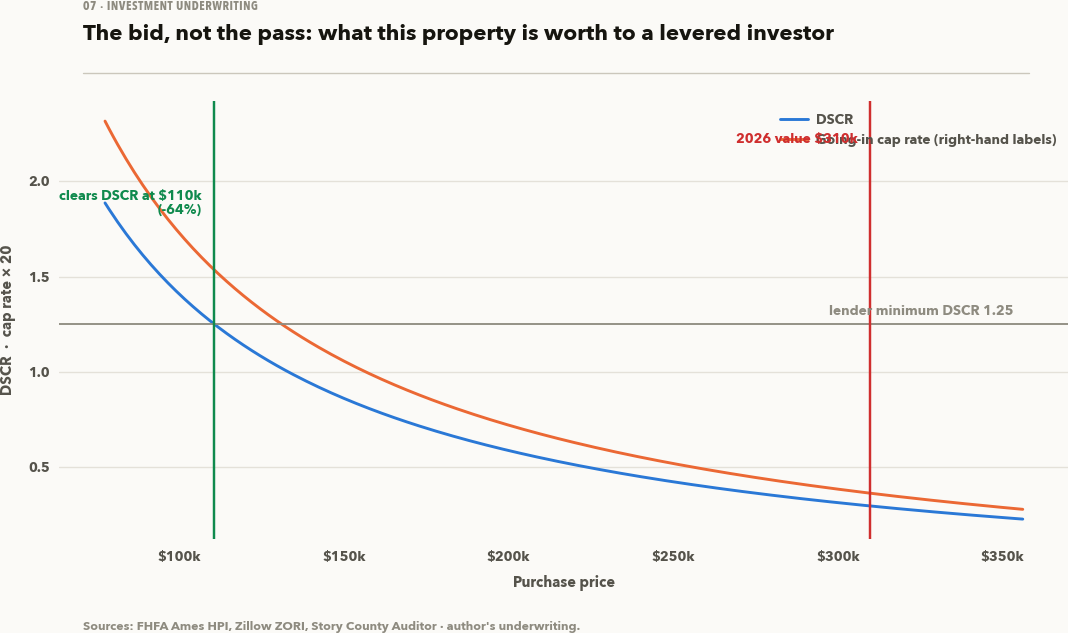

In [11]:
fig, ax = plt.subplots(figsize=(10.0, 6.3))
ax.plot(curve.index, curve["dscr"], color=BLUE, label="DSCR")
ax.plot(curve.index, curve["cap"] * 20, color=ORANGE,
        label="Going-in cap rate (right-hand labels)")
ax.axhline(1.25, color=INK_MUTED, lw=1.2)
annotate(ax, curve.index[-1], 1.25, "lender minimum DSCR 1.25", color=INK_MUTED,
         offset=(-6, 8), ha="right")
ax.axvline(ask, color=STATUS["critical"], lw=1.6)
annotate(ax, ask, ax.get_ylim()[1] * 0.92, f"2026 value {money(ask)}",
         color=STATUS["critical"], offset=(-8, 0), ha="right")
if np.isfinite(dscr_price):
    ax.axvline(dscr_price, color=STATUS["good"], lw=1.6)
    annotate(ax, dscr_price, ax.get_ylim()[1] * 0.78,
             f"clears DSCR at {money(dscr_price)}\n({dscr_price / ask - 1:.0%})",
             color=STATUS["good"], offset=(-8, 0), ha="right")
ax.xaxis.set_major_formatter(money)
ax.set_xlabel("Purchase price")
ax.set_ylabel("DSCR  ·  cap rate × 20")
ax.legend(loc="upper right")
finish(fig, "The bid, not the pass: what this property is worth to a levered investor")
save(fig, "07_bid_price")
plt.show()

Both series share one axis: the cap rate is rescaled onto the DSCR scale, because two independent y-axes would suggest a relationship between the series that is not in the data.

### Which exit binds?

`finance.underwrite` sets the exit value to the **greater** of two figures: forward NOI capitalised at the exit cap rate, and the price grown by house price appreciation (HPA). That convention needs justifying before the sensitivity analysis, because it decides the answer.

In [12]:
forward_rent = rent * (1 + BASE.rent_growth) ** BASE.hold_years
forward_value = ask * (1 + BASE.hpa) ** BASE.hold_years
forward_noi = net_operating_income(
    forward_rent, forward_value,
    BASE.with_(insurance_annual=BASE.insurance_annual
               * (1 + BASE.expense_growth) ** BASE.hold_years))["noi"]

exit_comparison = pd.Series({
    "Forward NOI (year 10)": forward_noi,
    f"Direct capitalisation at {BASE.exit_cap_rate:.1%}": forward_noi / BASE.exit_cap_rate,
    f"HPA-grown price at {BASE.hpa:.0%}/yr": forward_value,
    "Exit value used (the greater)": max(forward_noi / BASE.exit_cap_rate, forward_value),
}).to_frame("$")
exit_comparison.round(0)

,$
Forward NOI (year 10),7527.0
Direct capitalisation at 6.5%,115798.0
HPA-grown price at 3%/yr,416116.0
Exit value used (the greater),416116.0


**The income-based exit is nowhere near competitive, so the HPA branch always wins.**

This reflects how the market works rather than a quirk of the model. Ames single-family homes are priced by **owner-occupiers**, not investors. The capitalised-income figure is what a house is worth to someone buying a cash-flow stream; the HPA-grown figure is what it is worth to a family who wants to live in it. In Ames the second is several times the first, and the second sets the market.

The consequence, visible in the next section: **the exit cap rate is inert in this model.** It never binds, so it has zero sensitivity. Usually the exit cap tops the tornado chart, so this result could be mistaken for a bug.

## 4. Sensitivity

Which assumption moves the answer? Each is varied one at a time, with everything else at base.

In [13]:
# Human-readable names, because "hpa" and "ltv" are not words.
ASSUMPTION_LABELS = {
    "exit_cap_rate": "Exit cap rate", "mortgage_rate": "Mortgage rate",
    "rent_growth": "Rent growth", "hpa": "House price appreciation",
    "vacancy_rate": "Vacancy", "maintenance_rate": "Maintenance",
    "capex_reserve": "CapEx reserve", "management_fee": "Management fee",
    "property_tax_rate": "Property tax rate", "ltv": "Loan-to-value",
    "selling_cost_rate": "Selling costs",
}

RANGES = {
    "exit_cap_rate": (0.050, 0.080),
    "mortgage_rate": (0.0550, 0.0900),
    "rent_growth": (0.010, 0.050),
    "hpa": (0.000, 0.060),
    "vacancy_rate": (0.030, 0.120),
    "maintenance_rate": (0.050, 0.120),
    "capex_reserve": (0.030, 0.080),
    "management_fee": (0.000, 0.100),
    "property_tax_rate": (0.012, 0.017),
    "ltv": (0.60, 0.80),
    "selling_cost_rate": (0.04, 0.08),
}
torn = tornado(ask, rent, BASE, RANGES, metric="irr")
torn.round(4)

,assumption,low_input,high_input,low_output,high_output,base_output,swing
0,hpa,0.000,0.060,-0.1242,0.0577,-0.0139,0.1819
1,mortgage_rate,0.055,0.090,0.0161,-0.0449,-0.0139,0.0610
2,ltv,0.600,0.800,0.0073,-0.0242,-0.0139,0.0315
3,rent_growth,0.010,0.050,-0.0238,-0.0032,-0.0139,0.0206
4,management_fee,0.000,0.100,-0.0028,-0.0167,-0.0139,0.0139
5,property_tax_rate,0.012,0.017,-0.0074,-0.0205,-0.0139,0.0131
6,selling_cost_rate,0.040,0.080,-0.0076,-0.0206,-0.0139,0.0130
7,vacancy_rate,0.030,0.120,-0.0092,-0.0198,-0.0139,0.0106
8,maintenance_rate,0.050,0.120,-0.0098,-0.0195,-0.0139,0.0097
9,capex_reserve,0.030,0.080,-0.0112,-0.0181,-0.0139,0.0069


  saved reports/figures/07_tornado.png


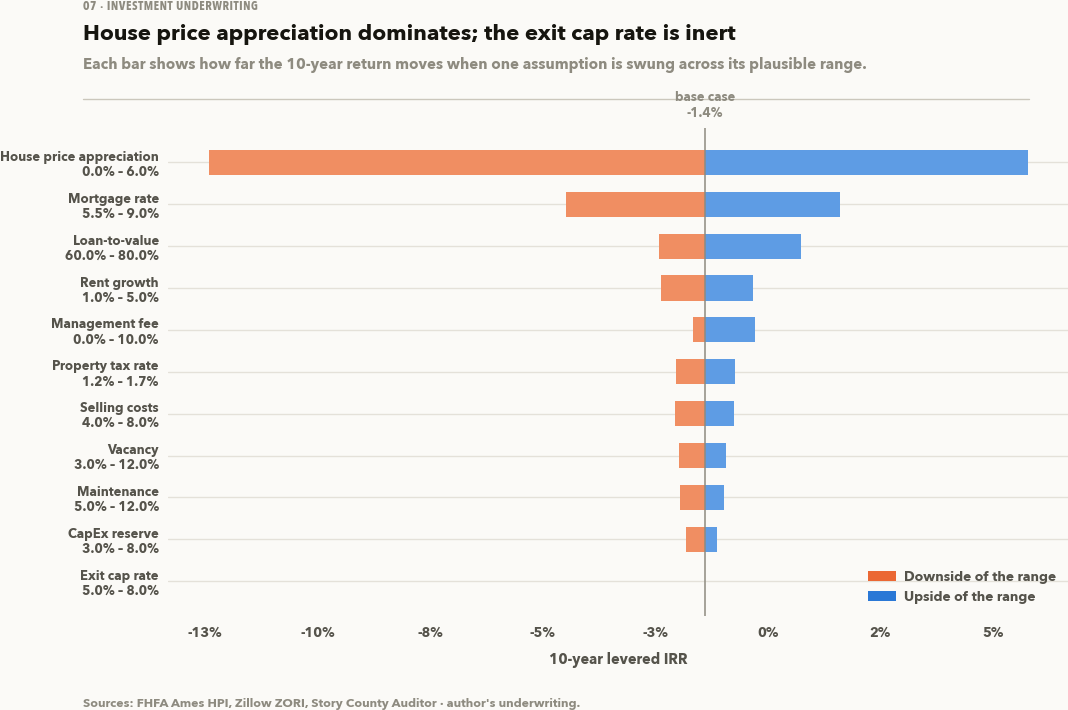

In [14]:
fig, ax = plt.subplots(figsize=(10.0, 7.0))
base_irr = torn["base_output"].iloc[0]
order = torn.iloc[::-1].reset_index(drop=True)
y = np.arange(len(order))
for i, row in order.iterrows():
    lo, hi = sorted([row["low_output"], row["high_output"]])
    ax.barh(i, lo - base_irr, left=base_irr, height=0.6, color=CONTRAST_FILL)
    ax.barh(i, hi - base_irr, left=base_irr, height=0.6, color=SUBJECT_FILL)
reference_line(ax, base_irr, f"base case\n{base_irr:.1%}", axis="x", color=INK_MUTED)
ax.set_yticks(y, [f"{ASSUMPTION_LABELS[r['assumption']]}\n"
                  f"{r['low_input']:.1%} – {r['high_input']:.1%}"
                  for _, r in order.iterrows()], fontsize=8.5)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("10-year levered IRR")
finish(fig, "House price appreciation dominates; the exit cap rate is inert",
       "Each bar shows how far the 10-year return moves when one assumption is swung "
       "across its plausible range.")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (ORANGE, BLUE)]
ax.legend(handles, ["Downside of the range", "Upside of the range"], loc="lower right")
save(fig, "07_tornado")
plt.show()

The ordering is unusual. **House price appreciation dominates, by a factor of three over the next driver**, and the exit cap rate, normally at or near the top of a real-estate tornado, contributes nothing, because the income-based exit never binds.

Together these repeat what the cash-flow analysis showed: this is not an income investment. Every operating assumption (vacancy, maintenance, management, capex, even the property tax rate) sits in the bottom half of the chart. The outcome rests on what the house is worth in ten years.

`property_tax_rate`, the one input here fully cited to a primary source, ranks low. The assumptions that matter most are the ones that cannot be looked up, which is the usual situation.

## 5. Monte Carlo

One-at-a-time sensitivity assumes the drivers move independently, and they do not. Notebook 02 measured the mechanism: at a fixed monthly payment, +100 bp of mortgage rate costs 9.4% of supportable price, so rates, prices and cap rates move together. A Monte Carlo simulation draws them jointly thousands of times to give a range of outcomes.

In [15]:
DEFAULT_CORRELATION

,rent_growth,hpa,exit_cap_rate,mortgage_rate
rent_growth,1.0,0.6,-0.20,0.10
hpa,0.6,1.0,-0.50,-0.10
exit_cap_rate,-0.2,-0.5,1.00,0.55
mortgage_rate,0.1,-0.1,0.55,1.00


In [16]:
sim = monte_carlo(ask, rent, BASE, n=4000, seed=SEED)
sim_summary = summarise_simulation(sim, metric="irr")
sim_summary.round(4).to_frame()

,irr
n,3966.0000
mean,-0.0293
p5,-0.2094
p25,-0.0696
median,-0.0079
p75,0.0351
p95,0.0896
P(irr < 0),0.5444
P(DSCR < 1.0),1.0000
P(DSCR < 1.25),1.0000


  saved reports/figures/07_monte_carlo.png


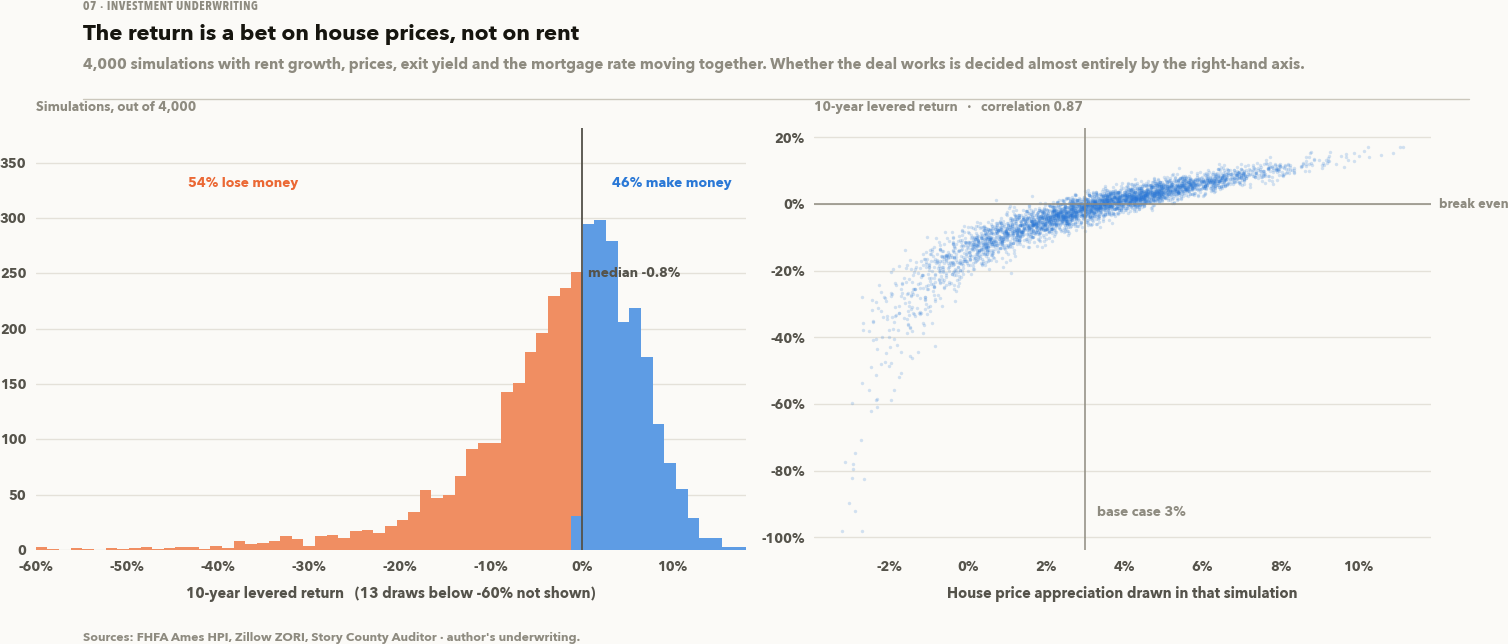

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.4),
                         gridspec_kw={"width_ratios": [1.15, 1]})

irr_vals = sim["irr"].dropna()
p_neg = (irr_vals < 0).mean()
median_irr = irr_vals.median()

ax = axes[0]
# Clip the far-left tail: a handful of draws reach -100% and squeeze the 95% of the
# distribution that anyone is actually deciding on into a sliver.
LO, HI = -0.60, irr_vals.max() * 1.05
clipped = int((irr_vals < LO).sum())
losses = irr_vals[(irr_vals < 0) & (irr_vals >= LO)]
gains = irr_vals[irr_vals >= 0]
bins = np.linspace(LO, HI, 62)
ax.hist(losses, bins=bins, color=CONTRAST_FILL)
ax.hist(gains, bins=bins, color=SUBJECT_FILL)
ax.axvline(0, color=INK_SECONDARY, lw=1.2)

top = ax.get_ylim()[1]
ax.set_ylim(0, top * 1.22)
annotate(ax, LO * 0.62, top * 1.06, f"{p_neg:.0%} lose money", color=CONTRAST,
         ha="center", offset=(0, 0), fontweight="demibold")
annotate(ax, HI * 0.55, top * 1.06, f"{1 - p_neg:.0%} make money", color=SUBJECT,
         ha="center", offset=(0, 0), fontweight="demibold")
annotate(ax, median_irr, top * 0.80, f"median {median_irr:.1%}", color=INK_SECONDARY,
         offset=(9, 0))
ax.set_xlim(LO, HI)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel(f"10-year levered return   ({clipped} draws below {LO:.0%} not shown)")
axis_note(ax, f"Simulations, out of {len(sim):,}")

ax = axes[1]
ax.scatter(sim["hpa"], sim["irr"], s=5, alpha=0.20, color=SUBJECT, linewidths=0)
reference_line(ax, 0, "break even", side="right")
ax.axvline(BASE.hpa, color=INK_MUTED, lw=1.0)
annotate(ax, BASE.hpa, sim["irr"].min(), f"base case {BASE.hpa:.0%}", color=INK_MUTED,
         offset=(8, 12))
corr = sim[["hpa", "irr"]].corr().iloc[0, 1]
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("House price appreciation drawn in that simulation")
axis_note(ax, f"10-year levered return   ·   correlation {corr:.2f}")

finish(fig, "The return is a bet on house prices, not on rent",
       "4,000 simulations with rent growth, prices, exit yield and the mortgage rate "
       "moving together. Whether the deal works is decided almost entirely by the "
       "right-hand axis.")
save(fig, "07_monte_carlo")
plt.show()

In [18]:
print(f"P(IRR < 0):        {(irr_vals < 0).mean():.1%}")
print(f"P(IRR < 8% hurdle): {(irr_vals < 0.08).mean():.1%}")
print(f"P(DSCR < 1.0):      {(sim['dscr'] < 1.0).mean():.1%}")
print(f"5th percentile IRR: {irr_vals.quantile(0.05):.1%}")
print(f"\ndraws with no IRR:  {len(sim) - len(irr_vals)} of {len(sim)} "
      f"(cash-flow stream never changes sign, so no rate zeroes the NPV)")

P(IRR < 0):        54.4%
P(IRR < 8% hurdle): 93.0%
P(DSCR < 1.0):      100.0%
5th percentile IRR: -20.9%

draws with no IRR:  34 of 4000 (cash-flow stream never changes sign, so no rate zeroes the NPV)


The IRR (annualised return, accounting for the timing of cash in and out) is not hopeless even where current cash flow is, because **the return comes almost entirely from appreciation and amortisation, not income.** A negative-cash-flow property whose IRR depends on the exit is a leveraged bet on house prices with a rental business attached, and should be sized as one.

## 6. The buy box

No property clears an institutional hurdle at the asking price. The ranking still shows which parts of the market come closest and what they have in common.

In [19]:
book["rent_yield"] = book["monthly_rent"] * 12 / book["value_2026"]
book["price_per_sqft"] = book["value_2026"] / book["sqft"]

screen = book.copy()
screen["passes_dscr"] = screen["dscr"] >= 1.25
screen["passes_cap"] = screen["cap_rate"] >= 0.06
screen["passes_coc"] = screen["cash_on_cash"] > 0

gate = pd.Series({
    "properties underwritten": len(screen),
    "DSCR >= 1.25": int(screen["passes_dscr"].sum()),
    "cap rate >= 6%": int(screen["passes_cap"].sum()),
    "positive cash-on-cash": int(screen["passes_coc"].sum()),
    "all three": int((screen["passes_dscr"] & screen["passes_cap"]
                      & screen["passes_coc"]).sum()),
}).to_frame("count")
gate["share"] = gate["count"] / len(screen)
gate.round(4)

,count,share
properties underwritten,2412,1.0000
DSCR >= 1.25,4,0.0017
cap rate >= 6%,23,0.0095
positive cash-on-cash,18,0.0075
all three,4,0.0017


In [20]:
top = book.nlargest(15, "cap_rate")[
    ["PID", "Neighborhood", "sqft", "beds", "quality", "year_built",
     "value_2026", "monthly_rent", "cap_rate", "dscr", "cash_on_cash", "irr"]]
top.round(4)

,PID,Neighborhood,sqft,beds,quality,year_built,value_2026,monthly_rent,cap_rate,dscr,cash_on_cash,irr
1350,911102170,IDOTRR,1317,3,4,1920,77950.3180,1552.5439,0.1252,2.0388,0.2362,0.3651
1687,902302150,OldTown,2337,5,5,1900,174581.6162,2606.1936,0.1011,1.6462,0.1469,0.2794
661,903476090,OldTown,1864,6,7,1902,187906.7766,2358.1074,0.0812,1.3231,0.0735,0.1984
611,902106060,OldTown,2372,4,5,1892,208490.6843,2484.3913,0.0771,1.2561,0.0582,0.1794
2207,902305090,OldTown,1774,4,4,1900,172239.3173,2027.2497,0.0730,1.1891,0.0430,0.1593
180,903454060,IDOTRR,1092,3,4,1930,106944.2615,1361.7259,0.0716,1.1657,0.0377,0.1520
1689,902304040,OldTown,2210,5,6,1880,226076.1256,2506.2257,0.0708,1.1539,0.0350,0.1482
668,904351240,Edwards,1112,4,5,1934,120785.9504,1461.8845,0.0690,1.1242,0.0282,0.1385
2345,909101190,SWISU,2230,5,4,1912,235910.4450,2522.0808,0.0679,1.1056,0.0240,0.1323
607,902103120,OldTown,1944,4,6,1910,199470.2706,2161.3600,0.0670,1.0911,0.0207,0.1273


In [21]:
nb_rank = (book.groupby("Neighborhood")
           .agg(n=("cap_rate", "size"), median_cap=("cap_rate", "median"),
                median_value=("value_2026", "median"),
                median_rent_yield=("rent_yield", "median"),
                median_psf=("price_per_sqft", "median"),
                median_dscr=("dscr", "median"))
           .query("n >= 15").sort_values("median_cap", ascending=False))

In [22]:
nb_rank.round(4)

,n,median_cap,median_value,median_rent_yield,median_psf,median_dscr
Neighborhood,,,,,,
MeadowV,34,0.0364,174171.9689,0.0860,171.0570,0.5925
SWISU,40,0.0344,261928.8913,0.0826,165.8887,0.5599
IDOTRR,68,0.0323,225442.1410,0.0809,177.2630,0.5266
OldTown,204,0.0304,238101.0499,0.0769,181.3851,0.4957
BrDale,26,0.0288,211772.0337,0.0767,191.3169,0.4692
Edwards,155,0.0267,243808.9459,0.0728,196.3826,0.4341
BrkSide,98,0.0265,249269.7951,0.0711,196.7945,0.4321
NPkVill,22,0.0251,281050.6421,0.0672,207.3937,0.4093
Gilbert,130,0.0213,357669.4926,0.0595,226.1947,0.3469


**Yield is highest at the bottom of the price range.** The cheapest neighborhoods have the highest cap rates because rent falls more slowly than price: a $100k house does not rent for a third of what a $300k house rents for.

Three qualifications for an investment committee:

1. The highest-yielding neighborhoods still sit **below the 4% band**, so this is a relative ranking within an unattractive market, not a buy list.
2. Low-priced housing carries higher maintenance and turnover than the flat 8%/5% used here, so the true spread is narrower than it appears.
3. The valuation is least precise at the bottom of the range: error dispersion in the cheapest valuation quintile is 0.123 against 0.084–0.106 elsewhere, and notebook 04 measures a real over-valuation of about 2–3% there. The segment that screens best is the one where the valuation is least certain, and notebook 08 turns that link into a credit number.

## 7. Persist

In [23]:
book.to_parquet(PROCESSED / "underwriting.parquet", index=False)
(PROCESSED / "underwriting_summary.json").write_text(json.dumps({
    "n_properties": int(len(book)),
    "median_value_2026": float(book["value_2026"].median()),
    "zhvi_latest": float(zhvi_latest),
    "fhfa_zhvi_gap": float(implied_median / zhvi_latest - 1),
    "median_monthly_rent": float(book["monthly_rent"].median()),
    "median_cap_rate": float(median_cap),
    "share_cap_in_band": float(in_band),
    "median_dscr": float(book["dscr"].median()),
    "share_dscr_above_125": float((book["dscr"] >= 1.25).mean()),
    "share_positive_coc": float((book["cash_on_cash"] > 0).mean()),
    "median_irr": float(book["irr"].median()),
    "mc_median_irr": float(irr_vals.median()),
    "mc_p_irr_negative": float((irr_vals < 0).mean()),
    "dscr_clearing_price": float(dscr_price) if np.isfinite(dscr_price) else None,
    "dscr_clearing_discount": float(dscr_price / ask - 1) if np.isfinite(dscr_price) else None,
    "top_tornado_driver": str(torn.iloc[0]["assumption"]),
}, indent=2))
print("wrote underwriting.parquet and underwriting_summary.json")

wrote underwriting.parquet and underwriting_summary.json


## 8. Summary

| Finding | Consequence |
|---|---|
| Median going-in cap rate is ~2–3%, outside the pre-committed 4–8% band | Flagged, investigated, and traced to fixed costs |
| Property tax + insurance take ~40% of EGI before any variable expense | Iowa's 1.45% effective rate scales with value while rent does not |
| The clearing price for a 1.25× DSCR is far below the 2026 value | The failed screen produces a bid price rather than a simple rejection |
| House price appreciation dominates the tornado; the exit cap is inert | The income-based exit never binds, because Ames is priced by owner-occupiers |
| Return is appreciation and amortisation, not income | Position size should treat it as a leveraged house-price bet |
| The highest-yielding segment is where the AVM is least accurate | Carried into nb 08 as a credit-risk concentration |